# hECA v2.0 -- Pooled scATAC-seq Across Five Organs

Source: Chen et al. 2025, Scientific Data. Zenodo record 15627886 (https://zenodo.org/records/15627886).

Five organs from the hECA v2.0 ATAC collection are pooled here to exceed 500,000 cells: Lung, Brain, Kidney, Heart, and Thymus. Cell types are harmonized by uHAF; cells the source could not classify (Unclassified) are dropped. The reference label used throughout this notebook is organ, which is unambiguous.

The pooled set spans several study_id values, so a pooled clustering may partly recover study of origin rather than biology.

---

## 0. Imports & Configuration

Runtime note: at SCALE = "publication" this notebook is expensive -- roughly a week of continuous compute at the n_jobs=1 it ships with. Measured order of magnitude: about 24 hours for the k-based CARVE fit (Section 1), 61 hours for the Leiden resolution fit (Section 2), 69 hours for the scaling ladder (Section 3), and 5.6 hours for the CVI sweep (Section 4). The RandomForest classifier CARVE fits per resample, not the clustering itself, accounts for roughly 90 percent of that. Parallelizing is not a free win here: n_jobs is a core budget, and at n_jobs=1 the forest already uses every core. Raising it moves the parallelism from threads inside one forest to whole forests in separate worker processes, which does not oversubscribe but holds one fitted forest per worker, about 2 GB each at publication scale. The dev scale exists for fast iteration; its runtime is not informative about publication scale.

Loading note: the pooled embedding of every annotated cell (about 765,000 cells over the five organs) holds tens of GB in memory while it is computed and belongs on a large machine; once computed, its cache in data/hECA/ serves every scale, including dev. Without that cache, SCALE = "dev" draws its 25,000-cell subsample from the organ files first and computes the embedding on those rows only, which fits on a laptop. meta["embedding_population"] says which embedding a run used; dev results on the subsample-first embedding are for iterating on the notebook, not for reading numbers from.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from benchmarks._studies import (
    STUDIES,
    carve_cache_path,
    cvi_sweep,
    fit_or_load_carve,
    load_study,
    study_model_grids,
    study_resolution_grids,
    study_scaling_sweep,
)
from benchmarks.figures import (
    figure_heca_results,
    figure_reference_scatter,
    figure_study_scaling,
    prepare_composite,
)
from benchmarks.figures._heca_results import (
    AXIS_LABELS,
    DEFAULT_SCATTER_SUBSAMPLE,
    MARKER_SIZE,
)
from benchmarks.figures._paths import CASE_STUDY_DIR

RANDOM_SEED = 42
SCALE = "dev"  # switch to "publication" for the manuscript run

# Scale-qualified output, so a development figure can never be mistaken for
# one that belongs in the manuscript.
OUT_DIR = CASE_STUDY_DIR if SCALE == "publication" else CASE_STUDY_DIR / SCALE
OUT_DIR.mkdir(parents=True, exist_ok=True)

study = STUDIES["heca"]
model_grids = study_model_grids(study)
X, y, meta = load_study(study, scale=SCALE)
print(
    meta["n_cells"], "cells across", meta["organs"], "|", meta["scale"],
    "| embedding computed on the", meta["embedding_population"],
)


def show(fig):
    display(fig)
    plt.close(fig)

25000 cells across ['Lung', 'Brain', 'Kidney', 'Heart', 'Thymus'] | dev | embedding computed on the subsample


### 0.1 Reference Labels

UMAP of the 50 principal components the loader returns, colored by organ, the reference label CARVE is scored against. The source ships no coordinates, so the embedding is computed here, the way the source publication visualizes its data. A seeded UMAP runs single-threaded: about a minute at the development scale and tens of minutes at publication scale, which is negligible beside the fits below. At publication scale the scatter draws a fixed subsample of cells, the same size the composite figure's scatter panels use. The composite in Section 4 draws the same embedding, with the same colors.

/Users/kaiwycik/GitHub/CARVE/code/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


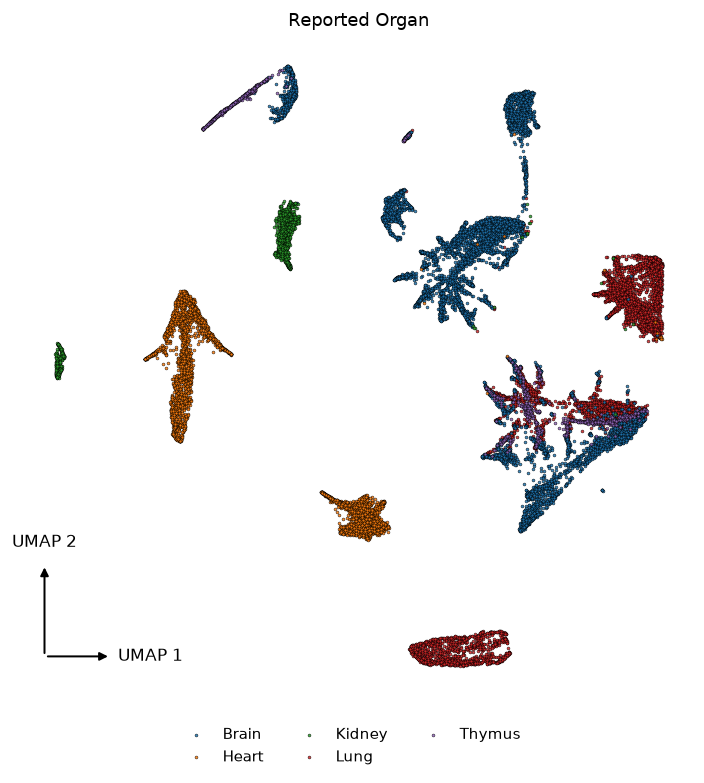

In [2]:
import umap

reference_embedding = umap.UMAP(random_state=RANDOM_SEED).fit_transform(X)
show(
    figure_reference_scatter(
        reference_embedding, y.to_numpy(),
        axis_labels=AXIS_LABELS, title="Reported Organ",
        max_points=DEFAULT_SCATTER_SUBSAMPLE, marker_size=MARKER_SIZE,
        out_dir=OUT_DIR, save_name="heca_reference_scatter.png",
    )
)

---

## 1. CARVE Analysis

CARVE is fit once at case-study scale using consensus_anchors=study.consensus_anchors, so the consensus matrix stays an anchor-by-anchor block rather than the full n-by-n matrix, which does not fit at this scale.

In [ ]:
carve = fit_or_load_carve(
    X, y,
    cache_path=carve_cache_path(
        study, scale=SCALE, root=Path("./carve_state_saves")
    ),
    n_jobs=-1,
    model_grids=model_grids,
    random_state=RANDOM_SEED,
    consensus_anchors=study.consensus_anchors,
)

/Users/kaiwycik/GitHub/CARVE/code/src/benchmarks/_studies.py:290: RuntimeWarning: consensus_anchors=2000 opts this run in regardless of anchor_threshold, so CARVE is using anchored consensus over 2000 anchors. Per-sample scores and labels still cover every sample; consensus matrices and PAC are computed over the anchors.
  carve.fit(np.asarray(X), reference_labels=reference)


---

## 2. Leiden Resolution Sweep

SweepSpec sweeps exactly one parameter, so a k-based run and a resolution-based run cannot share one CARVE object. This is a second, independent fit over the same anchored consensus path.

In [5]:
from carve import CARVE

leiden = CARVE(
    estimator_param_grids=study_resolution_grids(study),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    consensus_anchors=study.consensus_anchors,
).fit(X)
leiden.estimator_results_[["config_id", "resolution", "ari_stability"]]

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_84216/901278906.py:9: RuntimeWarning: consensus_anchors=2000 opts this run in regardless of anchor_threshold, so CARVE is using anchored consensus over 2000 anchors. Per-sample scores and labels still cover every sample; consensus matrices and PAC are computed over the anchors.
  ).fit(X)


,config_id,resolution,ari_stability
0,0,0.1,0.918069
1,1,0.2,0.906490
2,2,0.3,0.897241
3,3,0.4,0.917989
4,4,0.5,0.913304
5,5,0.6,0.866541
6,6,0.7,0.865397
7,7,0.8,0.848335
8,8,0.9,0.825516
9,9,1.0,0.829217


---

## 3. Scaling Ladder

Runtime, peak memory, and the selected k are measured at a ladder of subsample sizes drawn from the same pooled data, so the underlying biology is held fixed and n is the only thing varying between rungs. The development ladder stops at 25,000 cells; the publication ladder runs the full set of sizes up to every cell in the pooled dataset.

The 500,000 rung is a nominal target, not a verified count: the pooled total after the Unclassified drop is only known once the data is loaded. A rung larger than what is actually available is skipped with a warning rather than raised as an error, so an overestimate here costs a warning, not the hours of compute already spent on the smaller rungs.

In [ ]:
LADDER = {
    "dev": [5_000, 10_000, 25_000],
    "publication": [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, X.shape[0]],
}[SCALE]

sweep_df = study_scaling_sweep(
    X, y, sizes=LADDER, model_grids=model_grids,
    consensus_anchors=study.consensus_anchors, random_state=RANDOM_SEED,
)
show(figure_study_scaling(sweep_df, out_dir=OUT_DIR))
sweep_df

---

## 4. Quantitative Comparison

### 4.1 Composite Paper Figure (with ARI Comparison)

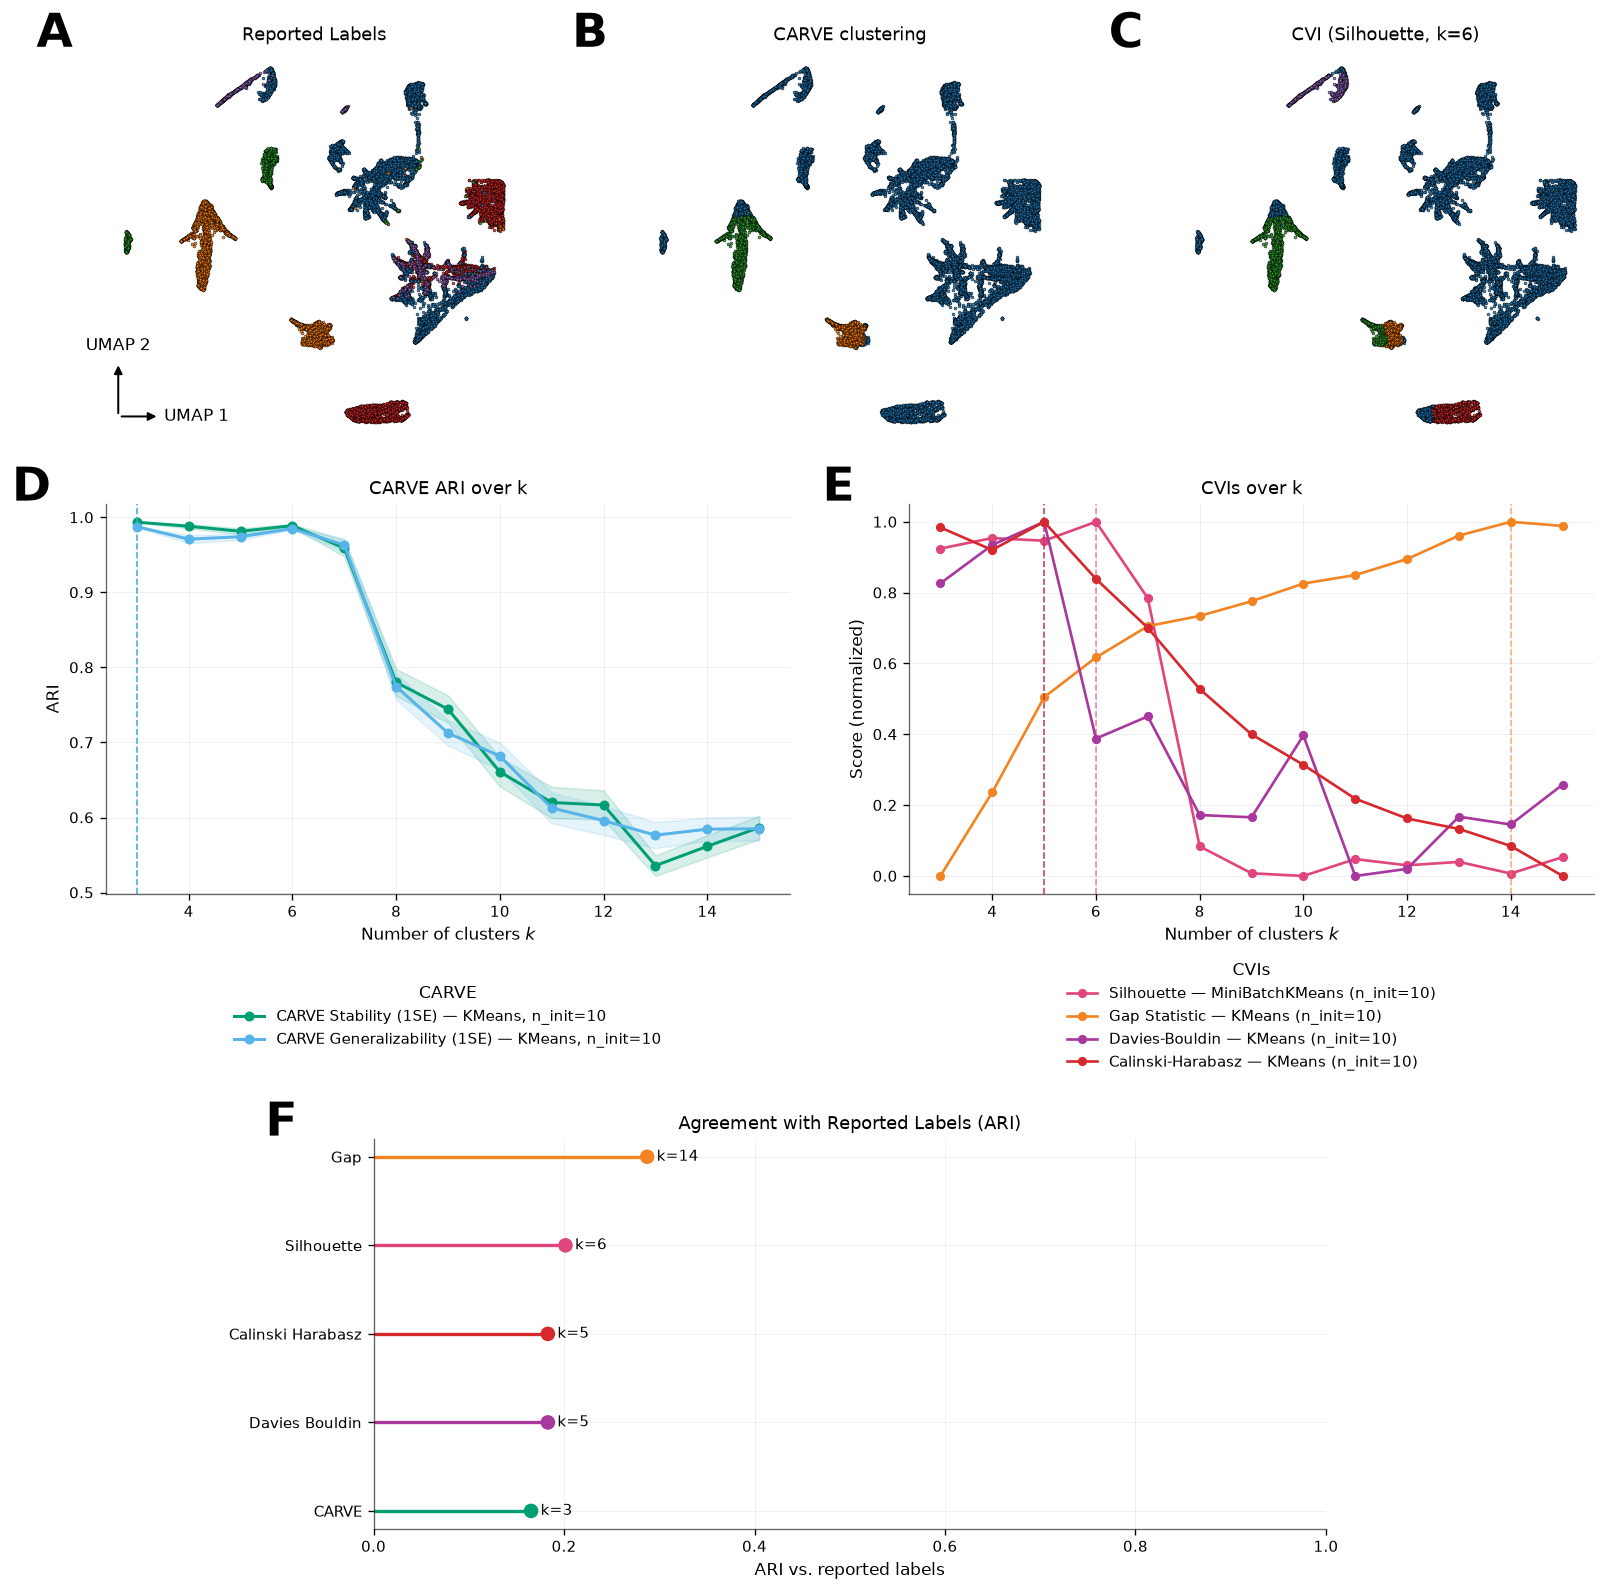

In [7]:
curves_df, best_df = cvi_sweep(
    X, y, model_grids=model_grids, candidate_k=study.candidate_k,
    random_state=RANDOM_SEED, n_jobs=-1,
)
inputs = prepare_composite(
    X, y.to_numpy(), carve, curves_df=curves_df, best_df=best_df,
    comparison_metric="silhouette", embedding=reference_embedding,
    measure="stability", rule="1se", random_state=RANDOM_SEED,
)
show(figure_heca_results(inputs, out_dir=OUT_DIR))

---

## 5. Summary

This case study exercises CARVE at the scale a reviewer explicitly asked about: hundreds of thousands of pooled scATAC-seq cells, well past where spectral or Ward agglomerative clustering, or an exact consensus matrix, remain options. The k-based and Leiden resolution runs above are two independent CARVE fits, compared by how well each one's selected clustering agrees with the reported organ labels and with each other. The scaling ladder quantifies what that scale costs directly, in runtime and peak memory, at the largest n reached.

---